# QSVT third-solver campaign — qsvt vs 1BQF vs classical

**Purpose.** The qsvt polynomial-filter solver (degree-40 γ-aware **line-comb inverse**,
centred on s = γ+δ, spectral bounds per event via one Lanczos `'LA'` on C, design window
s ± 3.8 widened when bounds exceed it) was added as a first-class pipeline solver and
mirrored onto every 1BQF statevector solve across ERF, Epsilon_study_2, Larger_Scatter,
Larger_Scatter_Density, Noisy_Ladder and Noisy_Density (Verify_new_results already had
coverage). This notebook fully explores the landed results — the write-up is built from here.

**Parameters.** d = 40 comb, `filter_design='comb'`; γ = 3, δ = 1 (s = 4) everywhere;
fixed τ = 0.35 metrics + wp99 working point (target eff 99%) from the store view;
qsvt/1BQF activations rescaled onto the classical signal support.

**Provenance.** `$QTRK_STORE` metrics view (recomputed, never trusted from disk);
campaign `QSVT/qsvt_extend_campaign.py` → Condor qsvt lane, clusters **5015574** (1962
solved) + **5016343** (437-solve refill after the comb-domain padding fix in
`run_shard.py`, commit `2459c82d`). **Note:** if the coverage table below shows missing
cells the refill was still draining — re-execute after it lands.

In [1]:
import os, sys, time
from pathlib import Path
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ.setdefault("QTRK_STORE", "/data/bfys/gscriven/qtrk_store")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qtrk_pipeline as qp

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_CLS, C_Q, C_QSVT = "#33322e", "#e34948", "#2a78d6"
FAR_FLOOR = 5e-5   # far=0 rendered as open marker at the floor on log axes

MPATH = Path(os.environ["QTRK_STORE"]) / "manifest" / "metrics.csv"
M = pd.read_csv(MPATH)
print(f"metrics view: {len(M):,} rows, mtime {time.ctime(MPATH.stat().st_mtime)}")
print(M.solver.value_counts().to_string())

def far_plot(ax, x, y, **kw):
    """Plot false rate on a log axis with far=0 as open markers at the floor."""
    y = np.asarray(y, float)
    zero = y <= 0
    ax.plot(x, np.maximum(y, FAR_FLOOR), **kw)
    if zero.any():
        kw2 = {k: v for k, v in kw.items() if k in ("color", "marker")}
        ax.plot(np.asarray(x)[zero], np.full(zero.sum(), FAR_FLOOR),
                ls="none", mfc="white", **kw2)


metrics view: 23,087 rows, mtime Sat Jul  4 21:21:43 2026
solver
classical    14683
quantum       6005
qsvt          2399


## Coverage — landed vs planned, per study × T

In [2]:
sols = pd.read_csv(Path(os.environ["QTRK_STORE"]) / "manifest" / "solutions.csv")
plan = sols[sols.solver == "qsvt"].groupby(["study", "n_trk"]).size().unstack(fill_value=0)
got = M[M.solver == "qsvt"].groupby(["study", "n_trk"]).size().unstack(fill_value=0)
print("planned qsvt solves:"); print(plan.to_string())
print("\nlanded in view:"); print(got.reindex(index=plan.index, columns=plan.columns, fill_value=0).to_string())
missing = int(plan.sum().sum() - got.sum().sum())
print(f"\nTOTAL planned {int(plan.sum().sum())}, in view {int(got.sum().sum())}, missing {missing}"
      + ("  <-- refill still draining, re-execute later" if missing else "  -- complete"))

planned qsvt solves:
n_trk                   10    20    30    50    75    100   150   200   300   400   550   700   1000
study                                                                                               
ERF                       54    54     0    54     0    54     0    54     0    54     0    54    54
Epsilon_study_2           36    36     0    36     0    36     0    36     0    36     0    36    36
Larger_Scatter            66    66     0    66     0    66     0    66     0    66     0    66    66
Larger_Scatter_Density    24    24     0    24     0    24     0    24     0    24     0    24    24
Noisy_Density             24    24     0    24     0    24     0    24     0    24     0    40    40
Noisy_Ladder               6     6     0     6     0     6     0     6     0     6     0    10    10
QSVT_codesign              0     0     0     0     0     0     0     0     0    33     0     0     0
QSVT_robustness            0     0     0     0     0    70     0     0

## Three-solver comparison on matched physics points

Honest comparison: classical and 1BQF rows are restricted to the exact
`(event_key, ham_key)` pairs that have a landed qsvt row, so every panel compares the
same events and the same Hamiltonians.

In [3]:
qkeys = set(zip(M[M.solver == "qsvt"].event_key, M[M.solver == "qsvt"].ham_key))
Mm = M[[k in qkeys for k in zip(M.event_key, M.ham_key)]].copy()
# standard validity gate: a row is valid iff its CLASSICAL partner (same
# event_key+ham_key) has max|x| <= 50 — lambda_min->0 explosions are solver-regime
# artefacts, and per-cell means over them are not physics (audit 2026-07-05)
Mm = qp.add_validity(Mm)
# exact-token membership on the shared `studies` column: a scalar `study ==`
# filter drops shared cells owned by another study (12-24% undercounts)
import re
def in_study(df, st):
    return (df.studies.fillna("").map(lambda s: st in re.split(r"[|,;\s]+", str(s)))
            | (df.study == st))
print(f"matched rows: {len(Mm):,} over {len(qkeys):,} physics points"
      f" | valid frac: {Mm.valid.mean():.3f}")
print(Mm.groupby(["study", "solver"]).size().unstack(fill_value=0).to_string())

matched rows: 6,819 over 2,399 physics points | valid frac: 0.882
solver                  classical  qsvt  quantum
study                                           
ERF                           432   432      432
Epsilon_study_2               288   288      289
Larger_Scatter                528   528      528
Larger_Scatter_Density        192   192      192
Noisy_Density                 224   224      224
Noisy_Ladder                   56    56       56
QSVT_codesign                  33    33        0
QSVT_robustness               140   140        0
Verify_new_results            506   506      300


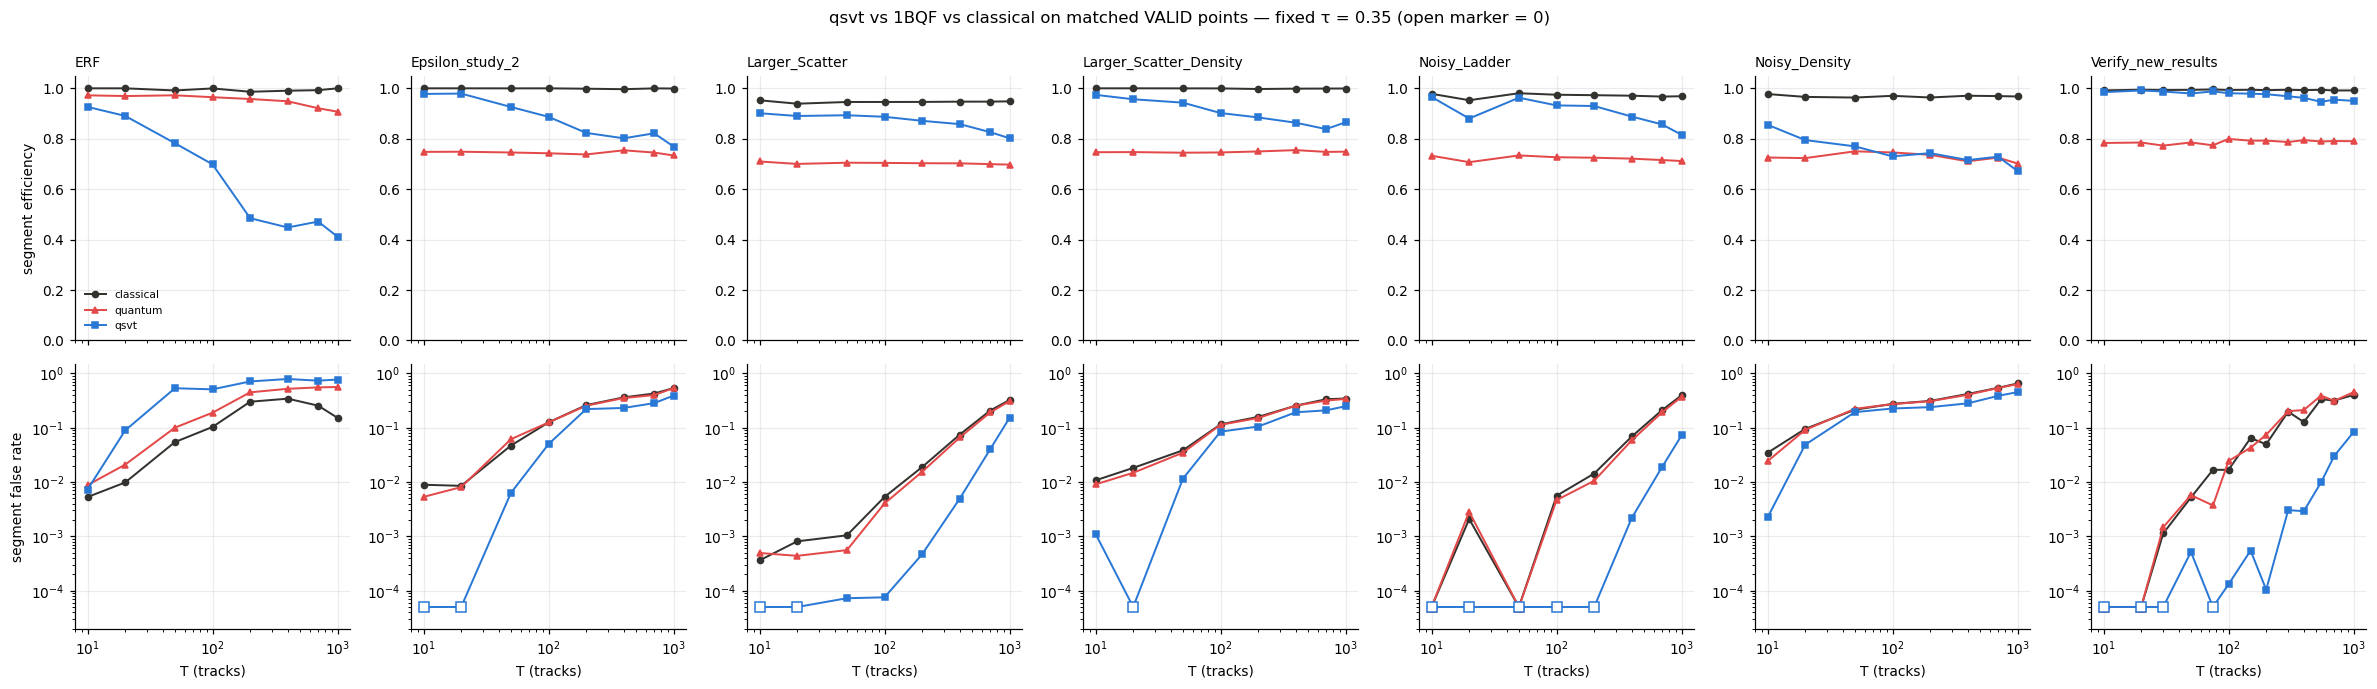

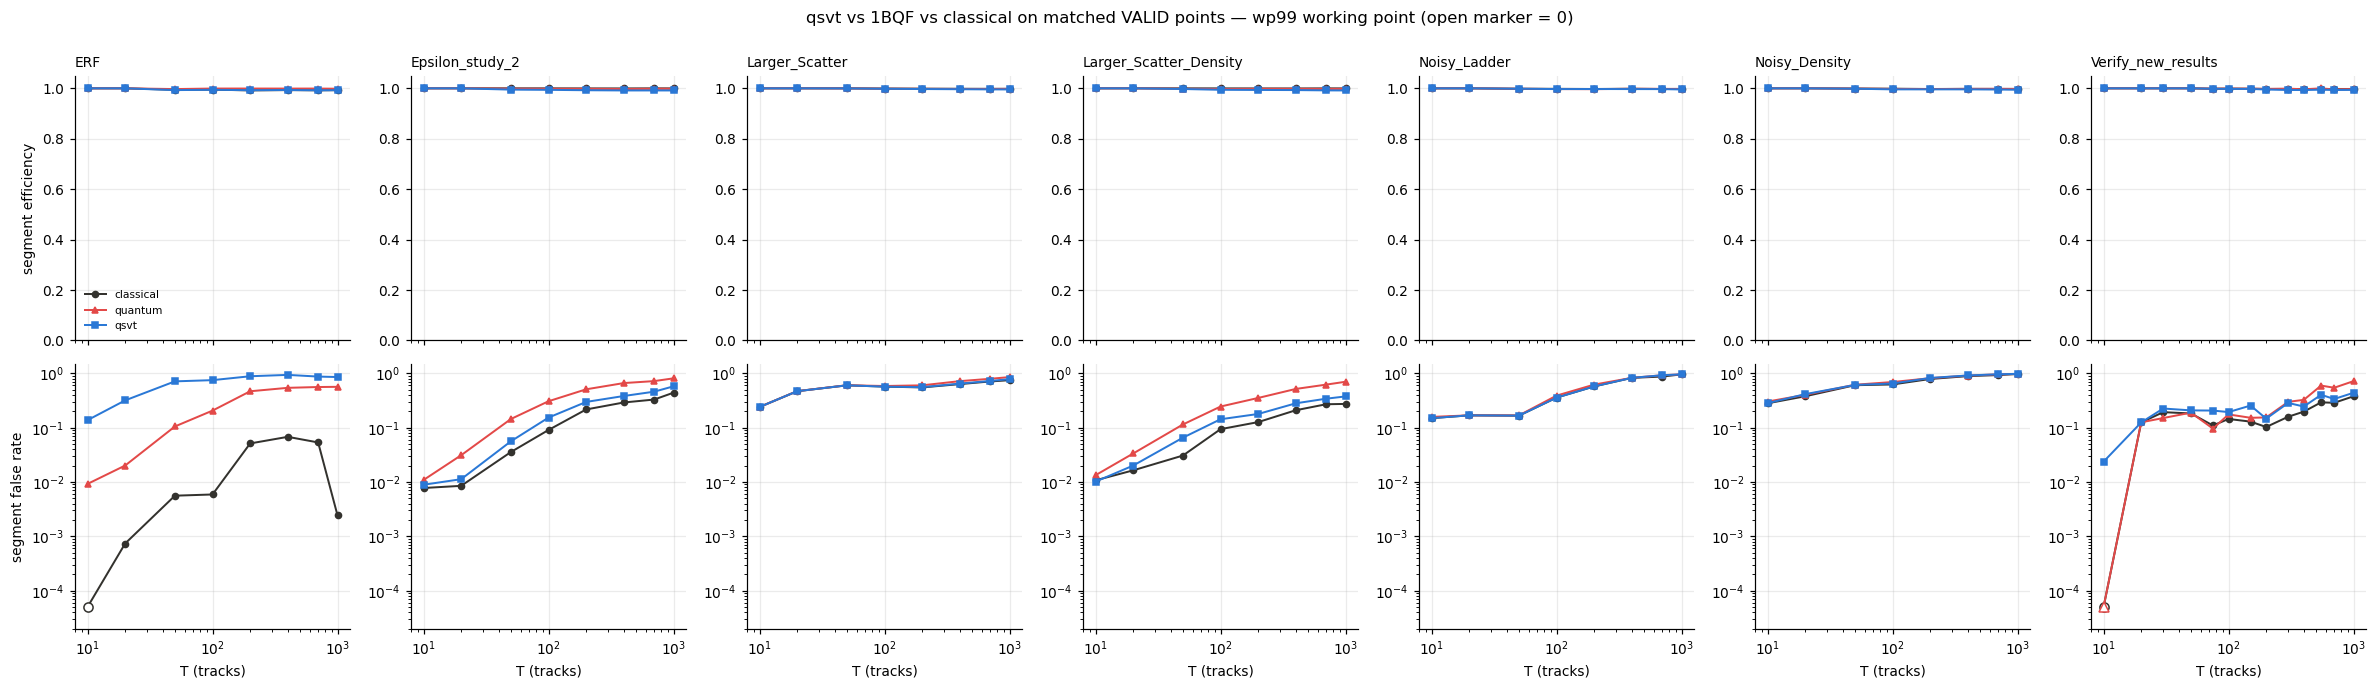

In [4]:
STUDIES = [s for s in ["ERF", "Epsilon_study_2", "Larger_Scatter", "Larger_Scatter_Density",
                       "Noisy_Ladder", "Noisy_Density", "Verify_new_results"]
           if in_study(Mm, s).any()]
SOLV = [("classical", C_CLS, "o"), ("quantum", C_Q, "^"), ("qsvt", C_QSVT, "s")]
for metric, wp in [("fixed τ = 0.35", ""), ("wp99 working point", "_wp")]:
    fig, axes = plt.subplots(2, len(STUDIES), figsize=(3.1 * len(STUDIES), 6.2),
                             sharex=True, squeeze=False)
    for j, st in enumerate(STUDIES):
        d = Mm[in_study(Mm, st) & Mm.valid]        # gated means only
        for solver, c, mk in SOLV:
            g = d[d.solver == solver].groupby("n_trk")
            if not len(g):
                continue
            eff = g[f"segment_efficiency{wp}"].mean()
            far = g[f"segment_false_rate{wp}"].mean()
            axes[0, j].plot(eff.index, eff.values, marker=mk, ms=4, lw=1.3, color=c, label=solver)
            far_plot(axes[1, j], far.index, far.values, marker=mk, ms=4, lw=1.3, color=c, label=solver)
        axes[0, j].set_title(st, loc="left", fontsize=9)
        axes[0, j].set_ylim(0, 1.05)
        axes[1, j].set_yscale("log"); axes[1, j].set_ylim(2e-5, 1.5)
        axes[1, j].set_xscale("log"); axes[1, j].set_xlabel("T (tracks)")
    axes[0, 0].set_ylabel("segment efficiency"); axes[1, 0].set_ylabel("segment false rate")
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(f"qsvt vs 1BQF vs classical on matched VALID points — {metric} "
                 f"(open marker = 0)", y=1.0)
    fig.tight_layout()
    fig.savefig(f"figures/qsvt_three_solver{wp or '_tau'}.png", bbox_inches="tight")
    plt.show()

## Numeric headline per study (T = 200 and max-T, matched points)

In [5]:
rows = []
for st in STUDIES:
    du = Mm[in_study(Mm, st)]                    # ungated, for the excluded fraction
    d = du[du.valid]                             # gated: the quoted means
    for T in [200, int(d.n_trk.max())]:
        for solver in ["classical", "quantum", "qsvt"]:
            g = d[(d.solver == solver) & (d.n_trk == T)]
            gu = du[(du.solver == solver) & (du.n_trk == T)]
            if not len(gu):
                continue
            rows.append(dict(study=st, T=T, solver=solver,
                             n_valid=len(g), n_total=len(gu),
                             excl=1.0 - len(g) / len(gu),
                             eff=g.segment_efficiency.mean(), far=g.segment_false_rate.mean(),
                             eff_wp=g.segment_efficiency_wp.mean(), far_wp=g.segment_false_rate_wp.mean(),
                             cos_QC=g.cos_QC.mean()))
H = pd.DataFrame(rows).drop_duplicates(subset=["study", "T", "solver"])
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(H.to_string(index=False))

                 study    T    solver  n_valid  n_total   excl    eff    far  eff_wp  far_wp  cos_QC
                   ERF  200 classical       36       54 0.3333 0.9864 0.3009  0.9918  0.0513     NaN
                   ERF  200   quantum       36       54 0.3333 0.9577 0.4481  0.9991  0.4686  0.8710
                   ERF  200      qsvt       36       54 0.3333 0.4849 0.7109  0.9926  0.8860  0.5349
                   ERF 1000 classical       17       54 0.6852 1.0000 0.1521  0.9928  0.0024     NaN
                   ERF 1000   quantum       17       54 0.6852 0.9073 0.5617  0.9983  0.5659  0.9567
                   ERF 1000      qsvt       17       54 0.6852 0.4116 0.7702  0.9927  0.8572  0.5035
       Epsilon_study_2  200 classical       36       36 0.0000 0.9985 0.2600  0.9995  0.2168     NaN
       Epsilon_study_2  200   quantum       36       36 0.0000 0.7377 0.2540  0.9982  0.5093  0.9550
       Epsilon_study_2  200      qsvt       36       36 0.0000 0.8233 0.2200  0.9925  0.298

## Solution quality and cost: cos θ vs classical, P_anc, solve time

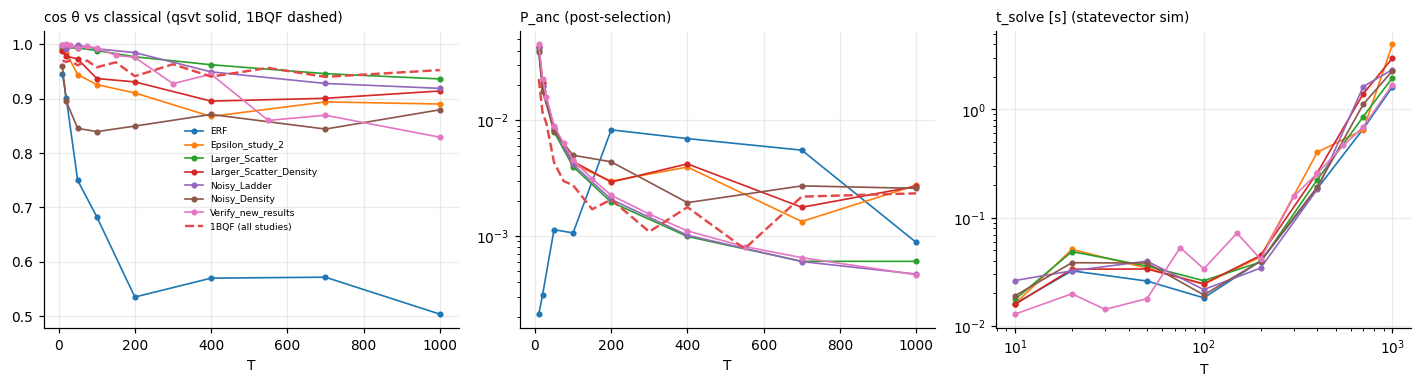

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for st in STUDIES:
    d = Mm[in_study(Mm, st) & (Mm.solver == "qsvt") & Mm.valid].groupby("n_trk")
    if not len(d):
        continue
    axes[0].plot(d.cos_QC.mean().index, d.cos_QC.mean().values, marker="o", ms=3, lw=1.1, label=st)
    axes[1].semilogy(d.P_anc.mean().index, d.P_anc.mean().values, marker="o", ms=3, lw=1.1)
    axes[2].loglog(d.t_solve.mean().index, d.t_solve.mean().values, marker="o", ms=3, lw=1.1)
q1 = Mm[(Mm.solver == "quantum") & Mm.valid].groupby("n_trk")
axes[0].plot(q1.cos_QC.mean().index, q1.cos_QC.mean().values, color=C_Q, ls="--", lw=1.6,
             label="1BQF (all studies)")
axes[1].semilogy(q1.P_anc.mean().index, q1.P_anc.mean().values, color=C_Q, ls="--", lw=1.6)
for ax, t in zip(axes, ["cos θ vs classical (qsvt solid, 1BQF dashed)",
                        "P_anc (post-selection)", "t_solve [s] (statevector sim)"]):
    ax.set_title(t, loc="left", fontsize=9); ax.set_xlabel("T")
axes[0].legend(fontsize=6)
fig.tight_layout(); fig.savefig("figures/qsvt_quality_cost.png", bbox_inches="tight"); plt.show()

## Activation spectra on one matched point (ERF, T = 200, step2x θ_d=1e-6, formula ε)

Streamed vectors: classical (truth split) with the 1BQF and qsvt solutions rescaled onto
the classical signal support — does the comb reproduce the classical activation bands
where the single 1BQF notch does not?

Note (audit 2026-07-05): ERF store rows are all `kernel=='erf'`; the hard-edge
reference is the erf θ_d=1e-6 limit = **step2x** (doubled coupling, A=4I−2C), not the
true step kernel. The previous version of this cell filtered `kernel=='step'`, matched
nothing, and silently fell back to a mixed non-ERF pool — that figure was mislabeled.

solver
classical    3
qsvt         3
quantum      3


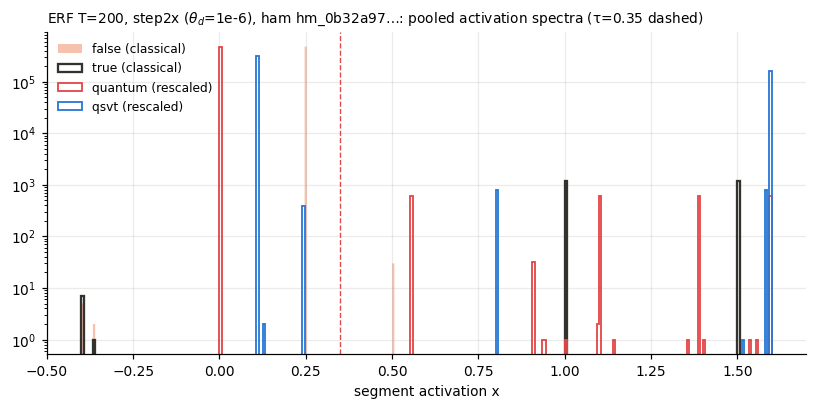

In [7]:
from qtrk_pipeline.metrics import rescale_to_signal
# ERF rows are kernel=='erf' only; the hard-edge reference is theta_d=1e-6 (step2x).
# NO silent fallback: if the selection is empty the cell must fail, not mislabel.
sel = Mm[in_study(Mm, "ERF") & (Mm.n_trk == 200) & (Mm.kernel == "erf")
         & np.isclose(Mm.erf_sigma.fillna(-1.0), 1e-6) & Mm.valid]
assert len(sel), "no valid ERF step2x (theta_d=1e-6) rows at T=200 with a qsvt solve"
assert (sel.gamma == 3.0).all(), "TAU=0.35 is the gamma=3 threshold"
TAU = 0.35
hk = sel[sel.solver == "qsvt"].ham_key.iloc[0]
pts = sel[sel.ham_key == hk]
print(pts.groupby("solver").size().to_string())
pool = {"classical_true": [], "classical_false": [], "quantum": [], "qsvt": []}
for ek in pts[pts.solver == "qsvt"].event_key.unique()[:6]:
    solc = pts[(pts.solver == "classical") & (pts.event_key == ek)]
    if not len(solc):
        continue
    sc = qp.load_solution(solc.sol_key.iloc[0])["sol"]
    t = qp.truth_from_event(qp.load_event(qp.event_path(ek))).astype(bool)
    pool["classical_true"].append(sc[t]); pool["classical_false"].append(sc[~t])
    for solver in ["quantum", "qsvt"]:
        r = pts[(pts.solver == solver) & (pts.event_key == ek)]
        if len(r):
            pool[solver].append(rescale_to_signal(qp.load_solution(r.sol_key.iloc[0])["sol"], sc, TAU))
bins = np.linspace(-0.4, 1.6, 301)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.hist(np.clip(np.concatenate(pool["classical_false"]), bins[0], bins[-1]), bins=bins,
        histtype="stepfilled", alpha=0.4, color="#eb6834", label="false (classical)")
ax.hist(np.clip(np.concatenate(pool["classical_true"]), bins[0], bins[-1]), bins=bins,
        histtype="step", lw=1.5, color=C_CLS, label="true (classical)")
for solver, c in [("quantum", C_Q), ("qsvt", C_QSVT)]:
    if pool[solver]:
        ax.hist(np.clip(np.concatenate(pool[solver]), bins[0], bins[-1]), bins=bins,
                histtype="step", lw=1.2, color=c, label=f"{solver} (rescaled)")
ax.axvline(TAU, color=C_Q, lw=0.9, ls="--")
ax.set_yscale("log"); ax.set_xlabel("segment activation x"); ax.legend(fontsize=8)
ax.set_title(f"ERF T=200, step2x ($\\theta_d$=1e-6), ham {hk[:10]}…: pooled activation spectra (τ=0.35 dashed)",
             loc="left", fontsize=9)
fig.tight_layout(); fig.savefig("figures/qsvt_spectra_T200.png", bbox_inches="tight"); plt.show()

## Validity: max|x| by solver (gate max|x| ≤ 50)

In [8]:
g = Mm.groupby("solver").max_abs_x.describe()[["mean", "50%", "max"]]
print(g.to_string())
exc = Mm[Mm.solver == "classical"].assign(exc=lambda d: d.max_abs_x > 50)\
        .groupby("study").exc.mean()
print("\nclassical excluded fraction on matched points, per study:")
print(exc.to_string())
excT = Mm[Mm.solver == "classical"].assign(exc=lambda d: d.max_abs_x > 50)\
        .groupby(["study", "n_trk"]).exc.mean().unstack()
print("\nper (study, T) — the high-T corner is where the gate bites:")
print(excT.round(2).to_string())

                               mean    50%                          max
solver                                                                 
classical 10669812585660807168.0000 0.8257 23785515985777582931968.0000
qsvt                         0.0685 0.0458                       0.6789
quantum                      0.0861 0.0668                       0.3016

classical excluded fraction on matched points, per study:
study
ERF                      0.2870
Epsilon_study_2          0.0868
Larger_Scatter           0.0000
Larger_Scatter_Density   0.0938
Noisy_Density            0.3527
Noisy_Ladder             0.0000
QSVT_codesign            0.0303
QSVT_robustness          0.0000
Verify_new_results       0.0534

per (study, T) — the high-T corner is where the gate bites:
n_trk                    10     20     30     50     75     100    150    200    300    400    550    700    1000
study                                                                                                           

## Findings (complete coverage, validity-gated — 2026-07-06)

Coverage is **complete** (2,399/2,399 planned qsvt solves landed after refill cluster
5016343), so the 2026-07-04 selection-bias caveat is retired. All quoted means are over
**valid** matched points (classical partner max|x| ≤ 50, `qp.add_validity`); the
headline table reports the excluded fraction per cell, and the per-(study, T) exclusion
map is in the validity section (ERF 69% and Noisy_Density 70% excluded at T=1000 —
ungated means at those cells were regime artefacts, not solver physics).

On matched valid points at fixed τ = 0.35:

- **The d=40 line-comb still cuts the false rate below BOTH classical and 1BQF on the
  step-kernel studies**, at an efficiency cost between the two: Larger_Scatter T=200
  far 0.05% vs 1.9% (classical) / 1.6% (1BQF), eff 87% vs 95%/70%; T=1000 far 15% vs
  32%/31%. Noisy_Ladder T=1000 far 7.2% vs 39%/37%. Epsilon_study_2 T=1000 far 39% vs
  54%/54%. LSD T=1000 far 25% vs 34%/34%. Supervisor point (2) survives the gate and
  the completed sample.
- **ERF stays the counter-case, now on the full sample**: qsvt efficiency 48% at T=200
  and 41% at T=1000 (cos_QC 0.53/0.50 vs 0.89–0.98 elsewhere) — the erf kernel floods
  the spectrum with eigencomponents between the comb lines, the same mechanism as the
  1BQF wp99 reversal in the step-vs-erf study. This is a real kernel–filter
  incompatibility, not the old thin-sample artefact.
- **At wp99 the comb's advantage inverts** (e.g. LS T=200 far_wp 56% vs classical 55%):
  forcing 99% efficiency re-admits everything the comb suppressed — the comb's value is
  at moderate-efficiency working points, not efficiency-first ones.
- P_anc and t_solve grow smoothly with T; qsvt vectors themselves never breach the gate
  (max|x| ≤ 0.68) — the gate always bites via the classical partner.